# 1. Import Module


In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


# 2. Load data

In [2]:
file = "C:/Users/USER-PC/QSAR_Code/Inhalation toxicity/datasetAcute_inh_REACH_ToxVal_st_.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[09:23:32] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[09:23:32] ERROR: Could not sanitize molecule ending on line 7797
[09:23:32] ERROR: Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[09:23:32] Can't kekulize mol.  Unkekulized atoms: 16 17 20 39 40 41 52
[09:23:32] ERROR: Could not sanitize molecule ending on line 31736
[09:23:32] ERROR: Can't kekulize mol.  Unkekulized atoms: 16 17 20 39 40 41 52
[09:23:32] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[09:23:32] ERROR: Could not sanitize molecule ending on line 48400
[09:23:32] ERROR: Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
[09:23:32] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
[09:23:32] ERROR: Could not sanitize molecule ending on line 56535
[09:23:32] ERROR: Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
Failed to patch pandas - unable to change molecule rendering


(677, 12)
(677, 12)


Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       'SMILES', 'Mol'],
      dtype='object')

In [4]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

In [6]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf['RowID'] = moldf.index
moldf.head(100)

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,SMILES,Mol,RowID
680,3321,106-69-4,,134.17356872558594,"hexane-1,2,6-triol",0,"InChI=1S/C6H14O3/c7-4-2-1-3-6(9)5-8/h6-9H,1-5H2",ECHA,A,,OCCCCC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x0000014F305...,680
493,3408; 4177,15375-84-5,,288.21087646484375,manganese(2+) ion disodium 2-({2-[bis(carboxyl...,0,InChI=1S/C10H16N2O8/c13-7(14)3-11(4-8(15)16)1-...,ECHA,A,,O=C(O)CN(CCN(CC(=O)O)CC(=O)O)CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,493
494,280,919-94-8,,116.20133972167969,-,0,"InChI=1S/C7H16O/c1-5-7(3,4)8-6-2/h5-6H2,1-4H3",ECHA,V,,CCOC(C)(C)CC,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,494
495,214,156-60-5,,96.94327545166016,"(E)-1,2-dichloroethene",0,InChI=1S/C2H2Cl2/c3-1-2-4/h1-2H,ECHA,V,,ClC=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,495
287,1932; 1942,93762-80-2,,222.40940856933594,"Alkenes, C15-18",0,InChI=1S/C16H30/c1-3-5-7-9-11-13-15-16-14-12-1...,ECHA,V,,CCCCC=CCCC=CCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,287
...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,3527; 3525; 3528; 3530; 3521; 3520; 3518; 3529...,27215-95-8,,126.23922729492189,non-1-ene,0,"InChI=1S/C9H18/c1-3-5-7-9-8-6-4-2/h3,5H,4,6-9H...",ECHA,V,,CC=CCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,462
408,156,54889-63-3,,200.31776428222656,"(1r,4r)-1,4-bis(ethoxymethyl)cyclohexane; (1s,...",0,InChI=1S/C12H24O2/c1-3-13-9-11-5-7-12(8-6-11)1...,ECHA,A,,CCOCC1CCC(COCC)CC1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,408
407,1117; 1119; 1120,106-94-5,,122.99168395996092,1-bromopropane,0,"InChI=1S/C3H7Br/c1-2-3-4/h2-3H2,1H3",ECHA,V,,CCCBr,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,407
406,949; 945; 948; 946; 944; 942; 943; 941,95-47-6,,106.16500091552734,"1,2-xylene",0,"InChI=1S/C8H10/c1-7-5-3-4-6-8(7)2/h3-6H,1-2H3",ECHA,V,,Cc1ccccc1C,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,406


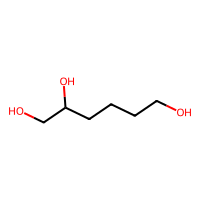

OCCCCC(O)CO


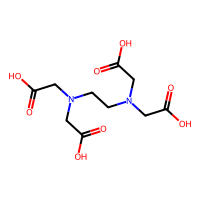

O=C(O)CN(CCN(CC(=O)O)CC(=O)O)CC(=O)O


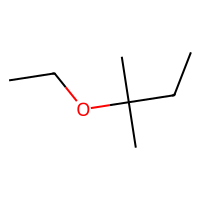

CCOC(C)(C)CC


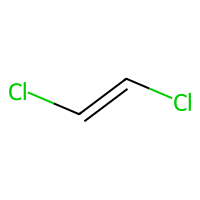

ClC=CCl


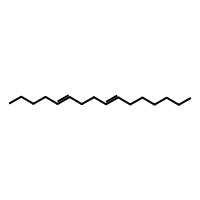

CCCCC=CCCC=CCCCCCC


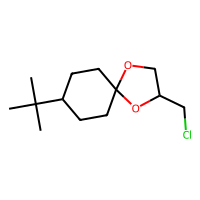

CC(C)(C)C1CCC2(CC1)OCC(CCl)O2


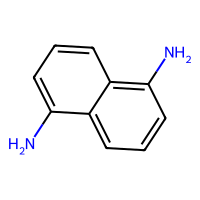

Nc1cccc2c(N)cccc12


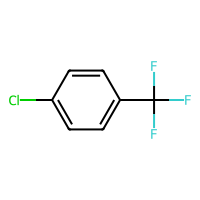

FC(F)(F)c1ccc(Cl)cc1


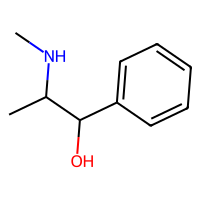

CNC(C)C(O)c1ccccc1


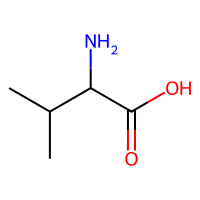

CC(C)C(N)C(=O)O


In [7]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(moldf, num_mols):
    for _, row in moldf.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


In [8]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from mordred import Calculator, descriptors
from fancyimpute import KNN


(CVXPY) Sep 12 02:12:00 PM: Encountered unexpected exception importing solver CVXOPT:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 12 02:12:00 PM: Encountered unexpected exception importing solver GLPK:
ImportError('DLL load failed while importing base: The specified module could not be found.')
(CVXPY) Sep 12 02:12:00 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError('DLL load failed while importing base: The specified module could not be found.')


## 3. Morgan, MACCsKeys, Modred

In [9]:
# Morgan fingerprints
nBits = 1024
radius = 2
useFeatures = False
moldf['Morgan_Descriptors'] = moldf['Mol'].apply(lambda mol: AllChem.GetMorganFingerprintAsBitVect(mol, nBits=nBits, radius=radius, useFeatures=useFeatures))

# MACCS keys
moldf['MACCS_Descriptors'] = moldf['Mol'].apply(lambda mol: MACCSkeys.GenMACCSKeys(mol))



In [10]:
from sklearn.preprocessing import StandardScaler
from rdkit import Chem
from mordred import Calculator, descriptors

# create descriptor calculator with all descriptors
calc = Calculator(descriptors, ignore_3D=True)
df = calc.pandas(moldf['Mol'])

 13%|█▎        | 91/677 [00:04<00:14, 41.75it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 34%|███▎      | 228/677 [00:06<00:07, 61.96it/s]

C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\USER-PC\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 677/677 [00:10<00:00, 63.53it/s] 


In [11]:
from fancyimpute import KNN
import pandas as pd
import numpy as np


df_numeric = df.select_dtypes(include=[float])  

df_filled = pd.DataFrame(KNN(k=3).fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)


Imputing row 1/677 with 0 missing, elapsed time: 0.567
Imputing row 101/677 with 0 missing, elapsed time: 0.568
Imputing row 201/677 with 0 missing, elapsed time: 0.568
Imputing row 301/677 with 0 missing, elapsed time: 0.569
Imputing row 401/677 with 0 missing, elapsed time: 0.569
Imputing row 501/677 with 0 missing, elapsed time: 0.570
Imputing row 601/677 with 0 missing, elapsed time: 0.570


In [12]:
X = np.array(df_filled)
scaler = StandardScaler()
x=  scaler.fit_transform(X)
moldf['Modred_Descriptor'] = x.tolist()

In [13]:
print(x.shape)

(677, 742)


In [14]:
moldf

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
680,3321,106-69-4,,134.17356872558594,"hexane-1,2,6-triol",0,"InChI=1S/C6H14O3/c7-4-2-1-3-6(9)5-8/h6-9H,1-5H2",ECHA,A,,OCCCCC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x0000014F305...,680,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3433004728566043, -0.4034423242722503, -0...."
493,3408; 4177,15375-84-5,,288.21087646484375,manganese(2+) ion disodium 2-({2-[bis(carboxyl...,0,InChI=1S/C10H16N2O8/c13-7(14)3-11(4-8(15)16)1-...,ECHA,A,,O=C(O)CN(CCN(CC(=O)O)CC(=O)O)CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,493,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7079472448861168, 0.3618252246148579, 0.410..."
494,280,919-94-8,,116.20133972167969,-,0,"InChI=1S/C7H16O/c1-5-7(3,4)8-6-2/h5-6H2,1-4H3",ECHA,V,,CCOC(C)(C)CC,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,494,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.524434643899268, 0.16599286764636892, 0.21..."
495,214,156-60-5,,96.94327545166016,"(E)-1,2-dichloroethene",0,InChI=1S/C2H2Cl2/c3-1-2-4/h1-2H,ECHA,V,,ClC=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,495,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8998151526605944, -1.7920132634094972, -1...."
287,1932; 1942,93762-80-2,,222.40940856933594,"Alkenes, C15-18",0,InChI=1S/C16H30/c1-3-5-7-9-11-13-15-16-14-12-1...,ECHA,V,,CCCCC=CCCC=CCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,287,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5103714290700143, -0.5272389881960475, -0.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,3640; 3638; 3639,107-22-2,,58.03607940673828,oxaldehyde,1,InChI=1S/C2H2O2/c3-1-2-4/h1-2H,ECHA,A,,O=CC=O,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,247,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8998151526605944, -1.7920132634094972, -1...."
246,1400,133-06-2,,300.5893249511719,"2-[(trichloromethyl)sulfanyl]-2,3,3a,4,7,7a-he...",1,"InChI=1S/C9H8Cl3NO2S/c10-9(11,12)16-13-7(14)5-...",ECHA,A,,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,246,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4981597938498981, 1.4022624399339063, 1.014..."
245,3459,2935-90-2,,120.17012023925781,methyl 3-sulfanylpropanoate,1,"InChI=1S/C4H8O2S/c1-6-4(5)2-3-7/h7H,2-3H2,1H3",ECHA,V,,COC(=O)CCS,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,245,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.583870075718577, -0.5138998626191917, -0.4..."
262,1868; 1869,4098-71-9,,222.2835235595703,"5-isocyanato-1-(isocyanatomethyl)-1,3,3-trimet...",1,InChI=1S/C12H18N2O2/c1-11(2)4-10(14-9-16)5-12(...,ECHA,A,,CC1(C)CC(N=C=O)CC(C)(CN=C=O)C1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,262,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37665263455285486, 1.1552229468658135, 1.21..."


In [15]:
moldf.keys()

Index(['id', 'casrn', 'smiles (First)', 'Molecular weight', 'name', 'Outcome',
       'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form', 'ID',
       'SMILES', 'Mol', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor'],
      dtype='object')

In [17]:
data = moldf

In [18]:
data 

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
680,3321,106-69-4,,134.17356872558594,"hexane-1,2,6-triol",0,"InChI=1S/C6H14O3/c7-4-2-1-3-6(9)5-8/h6-9H,1-5H2",ECHA,A,,OCCCCC(O)CO,<rdkit.Chem.rdchem.Mol object at 0x0000014F305...,680,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3433004728566043, -0.4034423242722503, -0...."
493,3408; 4177,15375-84-5,,288.21087646484375,manganese(2+) ion disodium 2-({2-[bis(carboxyl...,0,InChI=1S/C10H16N2O8/c13-7(14)3-11(4-8(15)16)1-...,ECHA,A,,O=C(O)CN(CCN(CC(=O)O)CC(=O)O)CC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,493,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.7079472448861168, 0.3618252246148579, 0.410..."
494,280,919-94-8,,116.20133972167969,-,0,"InChI=1S/C7H16O/c1-5-7(3,4)8-6-2/h5-6H2,1-4H3",ECHA,V,,CCOC(C)(C)CC,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,494,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.524434643899268, 0.16599286764636892, 0.21..."
495,214,156-60-5,,96.94327545166016,"(E)-1,2-dichloroethene",0,InChI=1S/C2H2Cl2/c3-1-2-4/h1-2H,ECHA,V,,ClC=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,495,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8998151526605944, -1.7920132634094972, -1...."
287,1932; 1942,93762-80-2,,222.40940856933594,"Alkenes, C15-18",0,InChI=1S/C16H30/c1-3-5-7-9-11-13-15-16-14-12-1...,ECHA,V,,CCCCC=CCCC=CCCCCCC,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,287,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5103714290700143, -0.5272389881960475, -0.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,3640; 3638; 3639,107-22-2,,58.03607940673828,oxaldehyde,1,InChI=1S/C2H2O2/c3-1-2-4/h1-2H,ECHA,A,,O=CC=O,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,247,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8998151526605944, -1.7920132634094972, -1...."
246,1400,133-06-2,,300.5893249511719,"2-[(trichloromethyl)sulfanyl]-2,3,3a,4,7,7a-he...",1,"InChI=1S/C9H8Cl3NO2S/c10-9(11,12)16-13-7(14)5-...",ECHA,A,,O=C1C2CC=CCC2C(=O)N1SC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,246,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4981597938498981, 1.4022624399339063, 1.014..."
245,3459,2935-90-2,,120.17012023925781,methyl 3-sulfanylpropanoate,1,"InChI=1S/C4H8O2S/c1-6-4(5)2-3-7/h7H,2-3H2,1H3",ECHA,V,,COC(=O)CCS,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,245,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.583870075718577, -0.5138998626191917, -0.4..."
262,1868; 1869,4098-71-9,,222.2835235595703,"5-isocyanato-1-(isocyanatomethyl)-1,3,3-trimet...",1,InChI=1S/C12H18N2O2/c1-11(2)4-10(14-9-16)5-12(...,ECHA,A,,CC1(C)CC(N=C=O)CC(C)(CN=C=O)C1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,262,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37665263455285486, 1.1552229468658135, 1.21..."


# 4. Split into Train and Test Data and Save into sdf file

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect



data = moldf.loc[:, ~data.columns.duplicated()]

# Split the data into train and test sets
train, test = train_test_split(data, test_size=0.2, random_state=42)

# Function to convert bit vectors to a list of integers
def bitvector_to_list(bitvector):
    if isinstance(bitvector, ExplicitBitVect):
        return list(map(int, bitvector.ToBitString()))
    else:
        return bitvector

# Convert bit vectors to lists before saving
def convert_bit_vectors(df):
    if 'Morgan_Descriptors' in df.columns:
        df['Morgan_Descriptors'] = df['Morgan_Descriptors'].apply(bitvector_to_list)
    if 'MACCS_Descriptors' in df.columns:
        df['MACCS_Descriptors'] = df['MACCS_Descriptors'].apply(bitvector_to_list)
    return df

# Convert bit vectors for train and test sets
train = convert_bit_vectors(train)
test = convert_bit_vectors(test)

# Function to save DataFrame to SDF
def save_to_sdf(df, filename):
    sdf_writer = Chem.SDWriter(filename)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mol.SetProp("_Name", str(idx))
            for col in df.columns:
                if col != 'Mol' and col != 'SMILES':
                    mol.SetProp(col, str(row[col]))
            sdf_writer.write(mol)
    sdf_writer.close()


# Save the train and test sets to SDF files
save_to_sdf(train, 'C:/Users/USER-PC/QSAR_Code/Inhalation toxicity/train_set_acute_inhalation_features.sdf')
save_to_sdf(test, 'C:/Users/USER-PC/QSAR_Code/Inhalation toxicity/test_set_acute_inhalation_features.sdf')

print("Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.")


Train and test sets saved to 'train_set.sdf' and 'test_set.sdf' respectively.


In [20]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Inhalation toxicity/train_set_acute_inhalation_features.sdf')
test_df = load_sdf_to_df('C:/Users/USER-PC/QSAR_Code/Inhalation toxicity/train_set_acute_inhalation_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

print("Test DataFrame:")
print(test_df.head())


Train DataFrame:
               id        casrn smiles (First)    Molecular weight  \
0      4154; 4153  117428-22-5                 367.31915283203125   
1          314292      75-01-4          ClC=C   62.49821853637695   
2  274214; 274217     624-54-4  CCCCCOC(=O)CC  144.21144104003906   
3            1404     120-55-8                    314.33251953125   
4            1403     112-27-6                 150.17295837402344   

                                      name Outcome  \
0                    unnamed [117428-22-5]       1   
1                           Vinyl chloride       0   
2                        Pentyl propionate       0   
3   2-[2-(benzoyloxy)ethoxy]ethyl benzoate       0   
4  2-[2-(2-hydroxyethoxy)ethoxy]ethan-1-ol       0   

                   Molecule (RDKit Mol) (InChI Code) reference  molecule_form  \
0  InChI=1S/C18H16F3NO4/c1-24-11-14(17(23)25-2)13...      ECHA              A   
1                     InChI=1S/C2H3Cl/c1-2-3/h2H,1H2  ToxValDB  not specified   


In [21]:
train_df

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,4154; 4153,117428-22-5,,367.31915283203125,unnamed [117428-22-5],1,InChI=1S/C18H16F3NO4/c1-24-11-14(17(23)25-2)13...,ECHA,A,,456,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.701154774912237, 0.956977040760475, 1.01715...",COC=C(C(=O)OC)c1ccccc1COc1cccc(C(F)(F)F)n1
1,314292,75-01-4,ClC=C,62.49821853637695,Vinyl chloride,0,"InChI=1S/C2H3Cl/c1-2-3/h2H,1H2",ToxValDB,not specified,,16,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5...",C=CCl
2,274214; 274217,624-54-4,CCCCCOC(=O)CC,144.21144104003906,Pentyl propionate,0,"InChI=1S/C8H16O2/c1-3-5-6-7-10-8(9)4-2/h3-7H2,...",ToxValDB,not specified,,114,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.20738333489899805, -0.37947237262897193, -...",CCCCCOC(=O)CC
3,1404,120-55-8,,314.33251953125,2-[2-(benzoyloxy)ethoxy]ethyl benzoate,0,InChI=1S/C18H18O5/c19-17(15-7-3-1-4-8-15)22-13...,ECHA,A,,270,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.463196836781069, 0.43272206674311153, 0.482...",O=C(OCCOCCOC(=O)c1ccccc1)c1ccccc1
4,1403,112-27-6,,150.17295837402344,2-[2-(2-hydroxyethoxy)ethoxy]ethan-1-ol,0,"InChI=1S/C6H14O4/c7-1-3-9-5-6-10-4-2-8/h7-8H,1...",ECHA,A,,670,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.19663915302663465, -0.6979548097454424, -0...",OCCOCCOCCO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,2563,75-07-0,,44.05255889892578,acetaldehyde,0,"InChI=1S/C2H4O/c1-2-3/h2H,1H3",ECHA,V,,230,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5...",CC=O
537,1687,54112-23-1,,476.5673828125,2-oxo-N-[4-({4-[(2-oxoazepane-1-carbonyl)amino...,0,InChI=1S/C27H32N4O4/c32-24-7-3-1-5-17-30(24)26...,ECHA,A,,399,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.892691368473904, 0.824198682880224, 0.86233...",O=C1CCCCCN1C(=O)Nc1ccc(Cc2ccc(NC(=O)N3CCCCCC3=...
538,802640,80-05-7,CC(C)(c1ccc(O)cc1)c2ccc(O)cc2,228.28634643554688,Bisphenol A,0,"InChI=1S/C15H16O2/c1-15(2,11-3-7-13(16)8-4-11)...",ToxValDB,not specified,,52,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6349761023089422, 1.1229232366580275, 1.186...",CC(C)(c1ccc(O)cc1)c1ccc(O)cc1
539,3216,74-90-8,,27.025339126586914,formonitrile,1,InChI=1S/CHN/c1-2/h1H,ECHA,G,,507,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.129111810898681, -4.038768238723913, -4.07...",C#N


In [22]:
train

,id,casrn,smiles (First),Molecular weight,name,Outcome,Molecule (RDKit Mol) (InChI Code),reference,molecule_form,ID,SMILES,Mol,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor
456,4154; 4153,117428-22-5,,367.31915283203125,unnamed [117428-22-5],1,InChI=1S/C18H16F3NO4/c1-24-11-14(17(23)25-2)13...,ECHA,A,,COC=C(C(=O)OC)c1ccccc1COc1cccc(C(F)(F)F)n1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,456,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.701154774912237, 0.956977040760475, 1.01715..."
16,314292,75-01-4,ClC=C,62.49821853637695,Vinyl chloride,0,"InChI=1S/C2H3Cl/c1-2-3/h2H,1H2",ToxValDB,not specified,,C=CCl,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F3...,16,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5..."
114,274214; 274217,624-54-4,CCCCCOC(=O)CC,144.21144104003906,Pentyl propionate,0,"InChI=1S/C8H16O2/c1-3-5-6-7-10-8(9)4-2/h3-7H2,...",ToxValDB,not specified,,CCCCCOC(=O)CC,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,114,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.20738333489899805, -0.37947237262897193, -..."
270,1404,120-55-8,,314.33251953125,2-[2-(benzoyloxy)ethoxy]ethyl benzoate,0,InChI=1S/C18H18O5/c19-17(15-7-3-1-4-8-15)22-13...,ECHA,A,,O=C(OCCOCCOC(=O)c1ccccc1)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,270,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.463196836781069, 0.43272206674311153, 0.482..."
670,1403,112-27-6,,150.17295837402344,2-[2-(2-hydroxyethoxy)ethoxy]ethan-1-ol,0,"InChI=1S/C6H14O4/c7-1-3-9-5-6-10-4-2-8/h7-8H,1...",ECHA,A,,OCCOCCOCCO,<rdkit.Chem.rdchem.Mol object at 0x0000014F305...,670,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.19663915302663465, -0.6979548097454424, -0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,2563,75-07-0,,44.05255889892578,acetaldehyde,0,"InChI=1S/C2H4O/c1-2-3/h2H,1H3",ECHA,V,,CC=O,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,230,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0522731682205035, -2.532966941311662, -2.5..."
399,1687,54112-23-1,,476.5673828125,2-oxo-N-[4-({4-[(2-oxoazepane-1-carbonyl)amino...,0,InChI=1S/C27H32N4O4/c32-24-7-3-1-5-17-30(24)26...,ECHA,A,,O=C1CCCCCN1C(=O)Nc1ccc(Cc2ccc(NC(=O)N3CCCCCC3=...,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,399,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2.892691368473904, 0.824198682880224, 0.86233..."
52,802640,80-05-7,CC(C)(c1ccc(O)cc1)c2ccc(O)cc2,228.28634643554688,Bisphenol A,0,"InChI=1S/C15H16O2/c1-15(2,11-3-7-13(16)8-4-11)...",ToxValDB,not specified,,CC(C)(c1ccc(O)cc1)c1ccc(O)cc1,<rdkit.Chem.rdchem.Mol object at 0x0000014F2F4...,52,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6349761023089422, 1.1229232366580275, 1.186..."
507,3216,74-90-8,,27.025339126586914,formonitrile,1,InChI=1S/CHN/c1-2/h1H,ECHA,G,,C#N,<rdkit.Chem.rdchem.Mol object at 0x0000014F304...,507,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.129111810898681, -4.038768238723913, -4.07..."
